In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv("data/food_waste_data.csv")

df.head()

,Date,Location,Food_Category,Food_Item,Quantity_Produced,Quantity_Sold,Quantity_Wasted,Cost_Per_Unit,Revenue_Per_Unit,Temperature,Customers
0,2024-01-01 00:00:00.000000000,Mumbai,Vegetables,Tomato,171,154,17,63.72,102.72,22.2,137.0
1,2024-01-01 11:41:16.050700466,Mumbai,Prepared Food,Burger,249,188,61,97.29,183.17,24.7,241.0
2,2024-01-01 23:22:32.101400933,Hyderabad,Vegetables,Tomato,413,248,165,10.64,14.00,31.5,219.0
3,2024-01-02 11:03:48.152101400,Mumbai,Vegetables,Spinach,463,308,155,98.49,160.22,38.9,184.0
4,2024-01-02 22:45:04.202801867,Bangalore,Prepared Food,Rice Bowl,487,355,132,96.91,180.82,26.7,102.0


In [3]:
df.columns

Index(['Date', 'Location', 'Food_Category', 'Food_Item', 'Quantity_Produced',
       'Quantity_Sold', 'Quantity_Wasted', 'Cost_Per_Unit', 'Revenue_Per_Unit',
       'Temperature', 'Customers'],
      dtype='str')

In [4]:
df = pd.read_csv("data/cleaned_food_waste_data.csv")

df.head()

,Date,Location,Food_Category,Food_Item,Quantity_Produced,Quantity_Sold,Quantity_Wasted,Cost_Per_Unit,Revenue_Per_Unit,Temperature,Customers,Month,Month_Name,Day,Day_Name,Waste_Percentage,Financial_Loss,Total_Revenue,Potential_Revenue,Waste_Risk
0,2024-01-01 00:00:00.000000000,Mumbai,Vegetables,Tomato,171,154,17,63.72,102.72,22.2,137.0,1,January,1,Monday,9.941520,1083.24,15818.88,17565.12,Low
1,2024-01-01 11:41:16.050700466,Mumbai,Prepared Food,Burger,249,188,61,97.29,183.17,24.7,241.0,1,January,1,Monday,24.497992,5934.69,34435.96,45609.33,Medium
2,2024-01-01 23:22:32.101400933,Hyderabad,Vegetables,Tomato,413,248,165,10.64,14.00,31.5,219.0,1,January,1,Monday,39.951574,1755.60,3472.00,5782.00,High
3,2024-01-02 11:03:48.152101400,Mumbai,Vegetables,Spinach,463,308,155,98.49,160.22,38.9,184.0,1,January,2,Tuesday,33.477322,15265.95,49347.76,74181.86,High
4,2024-01-02 22:45:04.202801867,Bangalore,Prepared Food,Rice Bowl,487,355,132,96.91,180.82,26.7,102.0,1,January,2,Tuesday,27.104723,12792.12,64191.10,88059.34,Medium


In [5]:
df.columns

Index(['Date', 'Location', 'Food_Category', 'Food_Item', 'Quantity_Produced',
       'Quantity_Sold', 'Quantity_Wasted', 'Cost_Per_Unit', 'Revenue_Per_Unit',
       'Temperature', 'Customers', 'Month', 'Month_Name', 'Day', 'Day_Name',
       'Waste_Percentage', 'Financial_Loss', 'Total_Revenue',
       'Potential_Revenue', 'Waste_Risk'],
      dtype='str')

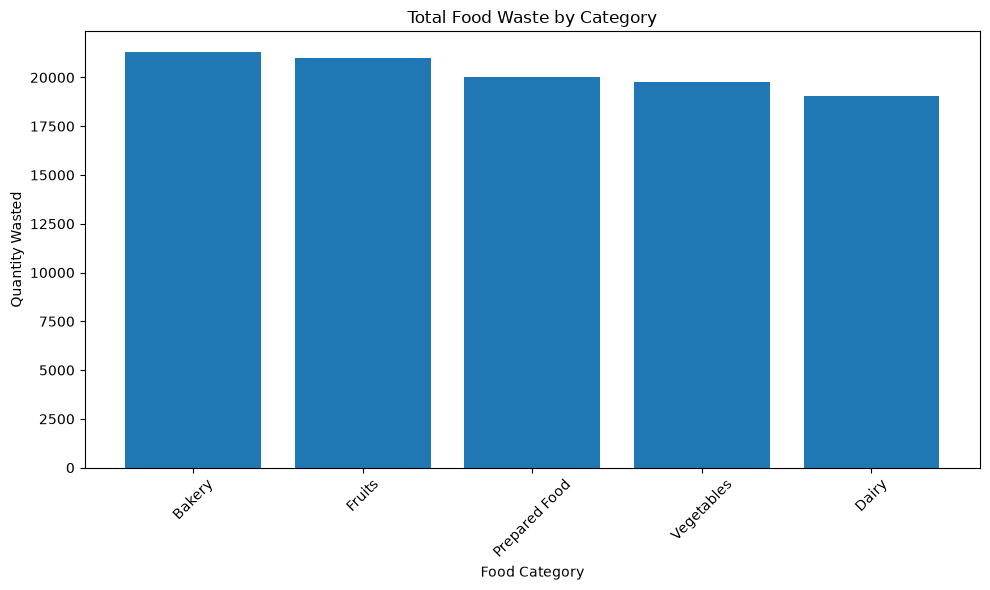

In [6]:
""" this graph is FOOD WASTE BY CATEGORY"""

category_waste = (
    df.groupby("Food_Category")["Quantity_Wasted"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    category_waste.index,
    category_waste.values
)

plt.title("Total Food Waste by Category")
plt.xlabel("Food Category")
plt.ylabel("Quantity Wasted")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

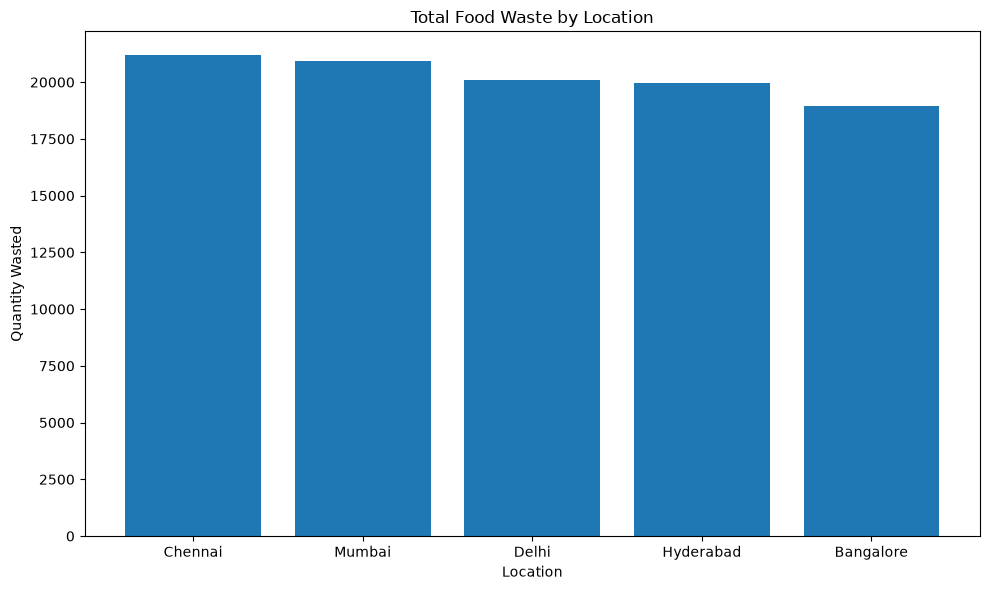

In [7]:
location_waste = (
    df.groupby("Location")["Quantity_Wasted"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    location_waste.index,
    location_waste.values
)

plt.title("Total Food Waste by Location")
plt.xlabel("Location")
plt.ylabel("Quantity Wasted")

plt.tight_layout()
plt.show()

In [8]:
top_wasted_items = (
    df.groupby("Food_Item")["Quantity_Wasted"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_wasted_items,
    x="Food_Item",
    y="Quantity_Wasted",
    title="Top 10 Most Wasted Food Items",
    labels={
        "Food_Item": "Food Item",
        "Quantity_Wasted": "Quantity Wasted"
    }
)

fig.show()

In [9]:
category_loss = (
    df.groupby("Food_Category")["Financial_Loss"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    category_loss,
    x="Food_Category",
    y="Financial_Loss",
    title="Financial Loss Due to Food Waste by Category",
    labels={
        "Food_Category": "Food Category",
        "Financial_Loss": "Financial Loss"
    },
    hover_data=["Financial_Loss"]
)

fig.show()

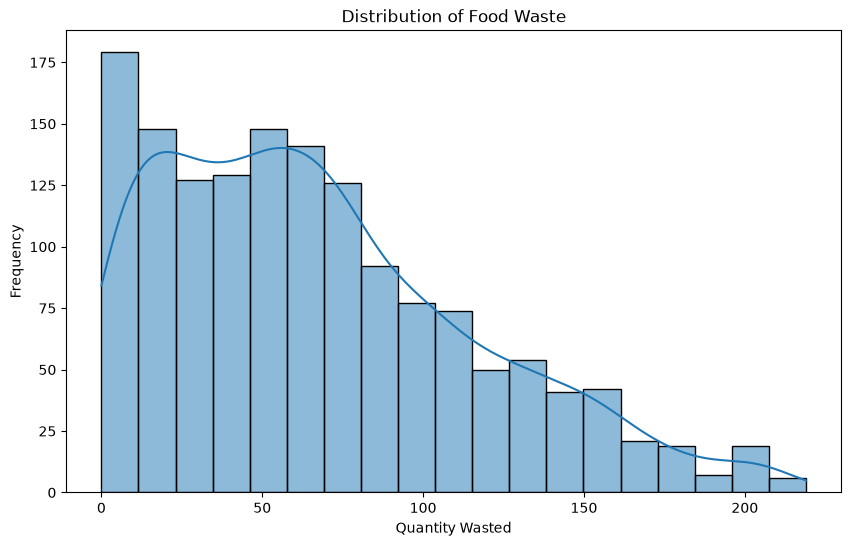

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Quantity_Wasted"],
    kde=True
)

plt.title("Distribution of Food Waste")
plt.xlabel("Quantity Wasted")
plt.ylabel("Frequency")

plt.show()

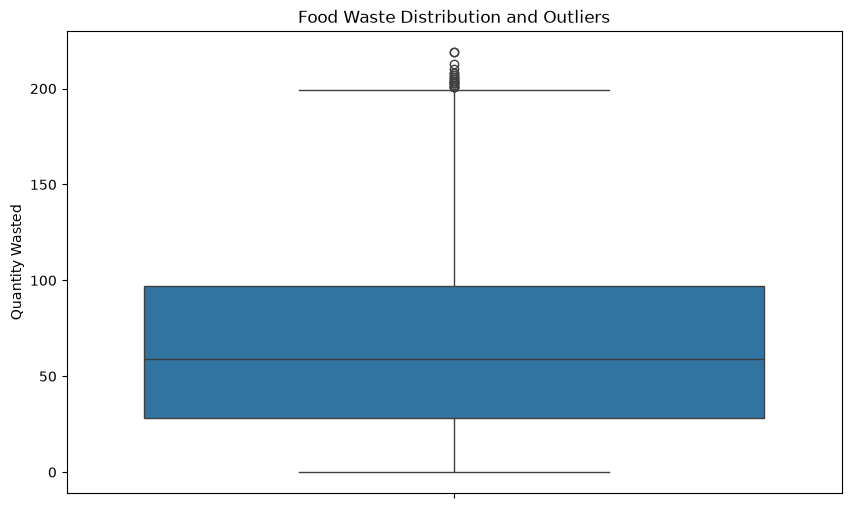

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    y=df["Quantity_Wasted"]
)

plt.title("Food Waste Distribution and Outliers")
plt.ylabel("Quantity Wasted")

plt.show()

In [12]:
fig = px.scatter(
    df,
    x="Temperature",
    y="Quantity_Wasted",
    title="Relationship Between Temperature and Food Waste",
    labels={
        "Temperature": "Temperature (°C)",
        "Quantity_Wasted": "Quantity Wasted"
    },
    hover_data=[
        "Location",
        "Food_Category",
        "Food_Item",
        "Waste_Percentage"
    ]
)

fig.show()

In [13]:
fig = px.scatter(
    df,
    x="Customers",
    y="Quantity_Wasted",
    title="Relationship Between Customers and Food Waste",
    labels={
        "Customers": "Number of Customers",
        "Quantity_Wasted": "Quantity Wasted"
    },
    hover_data=[
        "Location",
        "Food_Category",
        "Food_Item",
        "Waste_Percentage"
    ]
)

fig.show()

In [14]:
monthly_waste = (
    df.groupby(["Month", "Month_Name"])["Quantity_Wasted"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

In [15]:
fig = px.line(
    monthly_waste,
    x="Month_Name",
    y="Quantity_Wasted",
    title="Monthly Food Waste Trend",
    markers=True,
    labels={
        "Month_Name": "Month",
        "Quantity_Wasted": "Total Quantity Wasted"
    }
)

fig.show()

In [16]:
numerical_columns = [
    "Quantity_Produced",
    "Quantity_Sold",
    "Quantity_Wasted",
    "Cost_Per_Unit",
    "Revenue_Per_Unit",
    "Temperature",
    "Customers",
    "Waste_Percentage",
    "Financial_Loss",
    "Total_Revenue",
    "Potential_Revenue"
]

In [17]:
correlation_matrix = df[numerical_columns].corr()

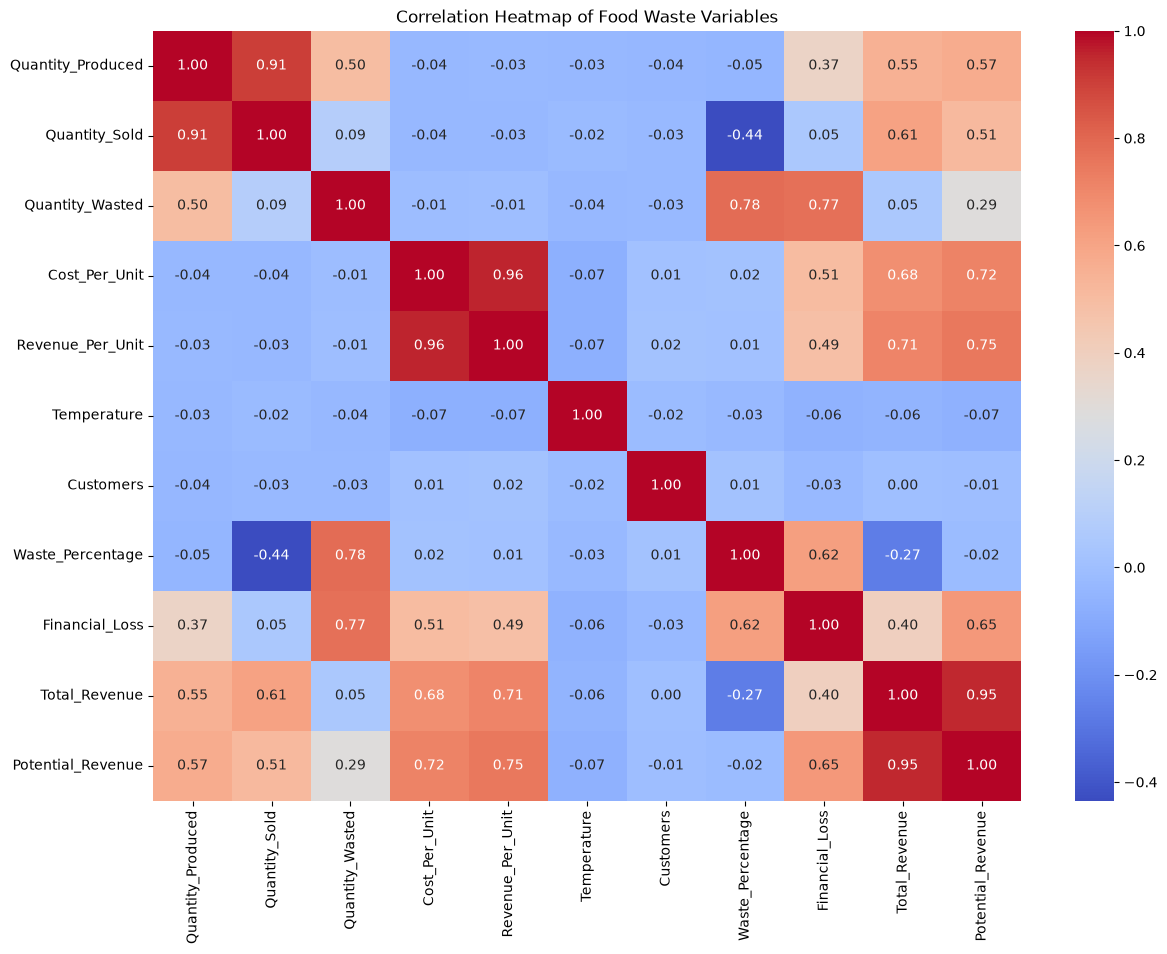

In [18]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Food Waste Variables")

plt.show()

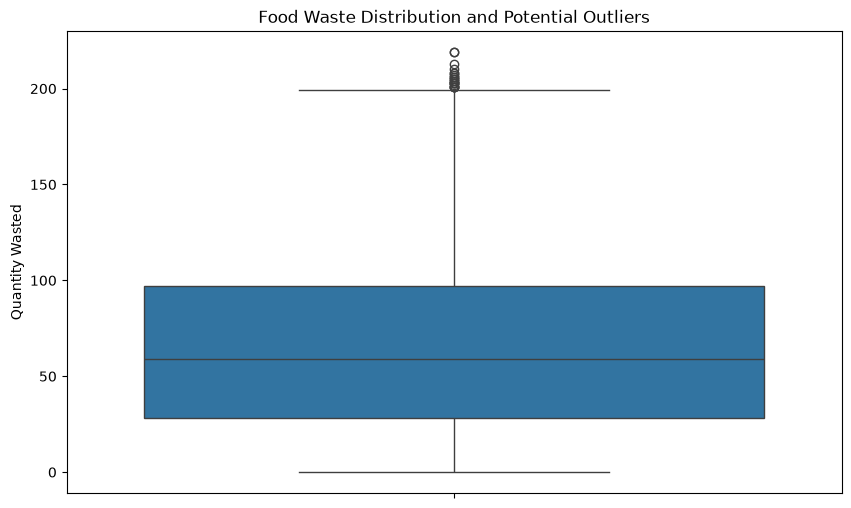

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    y=df["Quantity_Wasted"]
)

plt.title("Food Waste Distribution and Potential Outliers")
plt.ylabel("Quantity Wasted")

plt.show()

In [20]:
risk_distribution = (
    df["Waste_Risk"]
    .value_counts()
    .reset_index()
)

risk_distribution.columns = ["Waste_Risk", "Count"]

risk_distribution

,Waste_Risk,Count
0,Medium,519
1,Low,497
2,High,484


In [21]:
fig = px.pie(
    risk_distribution,
    names="Waste_Risk",
    values="Count",
    title="Distribution of Food Waste Risk Levels",
    hole=0.4
)

fig.show()